# 01 — U-Net Experiment
## Autonomous Terrain Traversability Analysis for Mars Rovers
### MSc Research Project — Model 1 of 7

**Project Title:** Autonomous Terrain Traversability Analysis for Mars Rovers Using Lightweight Semantic Segmentation  
**Dataset:** NASA AI4Mars (100 image-mask pairs)  
**Model:** U-Net (Baseline)  

---

### What this notebook does
- **Task 1:** Multi-class terrain segmentation (Soil / Bedrock / Sand / Big Rock)
- **Task 2:** Safe/Unsafe traversability mapping derived from Task 1 predictions

Run this notebook **top to bottom**. It will automatically create all outputs in the `outputs/` folder.

---

## Section 1 — Import Libraries

In [1]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os
import sys
import time
import logging
import warnings
from pathlib import Path

# ─── Numerical / Data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Image Processing ────────────────────────────────────────────────────────
from PIL import Image
import cv2

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ─── Torchvision ─────────────────────────────────────────────────────────────
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ─── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

# ─── Excel ───────────────────────────────────────────────────────────────────
import openpyxl
from openpyxl.styles import Font, Border, Side, PatternFill, Alignment
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')
print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"Python version  : {sys.version}")

All libraries imported successfully.
PyTorch version : 2.12.0
Python version  : 3.10.16 (main, Dec 11 2024, 10:22:29) [Clang 14.0.6 ]


## Section 2 — Configuration

**Edit the `DATA_ROOT` path below to point to your AI4Mars dataset folder.**  
All other paths are derived automatically.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROJECT CONFIGURATION — edit DATA_ROOT to match your local path
# ═══════════════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────────────
# Root of the ai4mars-dataset-merged-0.1 folder on your machine
DATA_ROOT = Path("/Users/rohannaidu/Desktop/Rohan/LJMU/Dataset/ai4mars-dataset-merged-0.1")

# Actual Mars images (EDR — grayscale JPG)
IMAGES_DIR = DATA_ROOT / "msl" / "images" / "edr"

# Segmentation labels (train split — cleaned, 3-labeller min, 2/3 agreement)
MASKS_DIR = DATA_ROOT / "msl" / "labels" / "train"

# Project output root (will be created automatically)
PROJECT_ROOT = Path("../../")       # notebook is in FT/notebooks/v2/
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
VERSION      = "v2"                  # ADD THIS LINE

MODEL_NAME   = "unet_v2"

SAVED_MODELS_DIR = OUTPUTS_DIR / "saved_models"         / VERSION / MODEL_NAME
PRED_TASK1_DIR   = OUTPUTS_DIR / "predictions_task1"    / VERSION / MODEL_NAME
TRAV_TASK2_DIR   = OUTPUTS_DIR / "traversability_task2" / VERSION / MODEL_NAME
VISUAL_DIR       = OUTPUTS_DIR / "visual_results"       / VERSION / MODEL_NAME
EXCEL_DIR        = OUTPUTS_DIR / "excel_results"        / VERSION
LOGS_DIR         = OUTPUTS_DIR / "logs"                 / VERSION
DATA_SPLIT_DIR   = PROJECT_ROOT / "data"

# ── Dataset Settings ──────────────────────────────────────────────────────────
NUM_IMAGES   = 500          # was 100
TRAIN_COUNT  = 350          # was 70
VAL_COUNT    = 75           # was 15
TEST_COUNT   = 75
IMAGE_SIZE   = (256, 256)   # (H, W)
RANDOM_SEED  = 42


# ── Class Labels ──────────────────────────────────────────────────────────────
NUM_CLASSES    = 4
CLASS_NAMES    = ["Soil", "Bedrock", "Sand", "Big Rock"]
IGNORE_INDEX   = 255        # NULL pixels in AI4Mars masks

# Task 2 traversability mapping
# Soil(0), Bedrock(1) → Safe(0) | Sand(2), Big Rock(3) → Unsafe(1)
TRAVERSABILITY_MAP = {0: 0, 1: 0, 2: 1, 3: 1}
TRAV_CLASS_NAMES   = ["Safe", "Unsafe"]

# ── Training Settings ─────────────────────────────────────────────────────────
BATCH_SIZE    = 4
NUM_EPOCHS    = 50
LEARNING_RATE = 0.001
NUM_WORKERS   = 0           # Set 0 for Mac M1 stability

# ── Device (Apple M1 = MPS, else CPU) ────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# ── Colours for visualisation ─────────────────────────────────────────────────
# Task 1: one RGB colour per terrain class
CLASS_COLOURS = {
    0: (180, 120,  60),   # Soil      — brown/yellow
    1: (128, 128, 128),   # Bedrock   — grey
    2: (255, 165,   0),   # Sand      — orange
    3: (220,  50,  50),   # Big Rock  — red
}
# Task 2: safe/unsafe colours
TRAV_COLOURS = {
    0: ( 50, 205,  50),   # Safe      — green
    1: (220,  50,  50),   # Unsafe    — red
}

# ── Create all output directories ────────────────────────────────────────────
for _dir in [SAVED_MODELS_DIR, PRED_TASK1_DIR, TRAV_TASK2_DIR,
             VISUAL_DIR, EXCEL_DIR, LOGS_DIR, DATA_SPLIT_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

print(f"Device          : {DEVICE}")
print(f"Images dir      : {IMAGES_DIR}")
print(f"Masks dir       : {MASKS_DIR}")
print(f"Outputs dir     : {OUTPUTS_DIR.resolve()}")
print("Configuration complete.")

Device          : mps
Images dir      : /Users/rohannaidu/Desktop/Rohan/LJMU/Dataset/ai4mars-dataset-merged-0.1/msl/images/edr
Masks dir       : /Users/rohannaidu/Desktop/Rohan/LJMU/Dataset/ai4mars-dataset-merged-0.1/msl/labels/train
Outputs dir     : /Users/rohannaidu/Desktop/Rohan/LJMU/outputs
Configuration complete.


## Section 3 — Logging Setup

A log file `unet.log` will be created in `outputs/logs/`.  
All important events during training and evaluation are recorded there.

In [3]:
def setup_logger(log_path: Path) -> logging.Logger:
    """
    Create and configure a logger that writes to both the notebook
    output (console) and a persistent log file.

    Args:
        log_path: Full path to the .log file.

    Returns:
        Configured logging.Logger instance.
    """
    logger = logging.getLogger(MODEL_NAME)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()          # avoid duplicate handlers on re-run

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # File handler — persists across notebook runs
    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    # Console handler — visible in notebook
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


LOG_PATH = LOGS_DIR / f"{MODEL_NAME}.log"
logger   = setup_logger(LOG_PATH)

logger.info(f"========== {MODEL_NAME.upper()} NOTEBOOK STARTED ==========")
logger.info(f"Device : {DEVICE}")
logger.info(f"Log file: {LOG_PATH}")

2026-05-26 08:39:13 | INFO     | ========== UNET_V2 NOTEBOOK STARTED ==========
2026-05-26 08:39:13 | INFO     | Device : mps
2026-05-26 08:39:13 | INFO     | Log file: ../outputs/logs/unet_v2.log


## Section 4 — Load Dataset

We scan the `edr` images folder and match each image with its corresponding mask in the `train` labels folder.  
Only the first 100 matched pairs are used (configurable via `NUM_IMAGES`).

In [5]:
def create_split_files(
    pairs: list,
    split_dir: Path,
    train_count: int,
    val_count: int,
    test_count: int,
    seed: int
) -> tuple:
    """
    Split matched pairs into train/val/test and save to .txt files.
    Uses a fixed seed for reproducibility across all notebooks.
    """
    np.random.seed(seed)
    indices = np.random.permutation(len(pairs))

    train_idx = indices[:train_count]
    val_idx   = indices[train_count:train_count + val_count]
    test_idx  = indices[train_count + val_count:train_count + val_count + test_count]

    train_pairs = [pairs[i] for i in train_idx]
    val_pairs   = [pairs[i] for i in val_idx]
    test_pairs  = [pairs[i] for i in test_idx]

    for fname, split in [("train.txt", train_pairs),
                          ("val.txt",   val_pairs),
                          ("test.txt",  test_pairs)]:
        with open(split_dir / fname, "w") as f:
            for img_p, msk_p in split:
                f.write(f"{img_p}\t{msk_p}\n")

    logger.info(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")
    return train_pairs, val_pairs, test_pairs

def find_diverse_pairs(
    images_dir: Path,
    masks_dir: Path,
    num_images: int,
    min_class_pixels: int = 100
) -> list:
    """
    Select image-mask pairs ensuring all 4 terrain classes are represented.
    
    Strategy:
        1. Scan ALL available masks and count pixels per class.
        2. Skip masks that are mostly NULL or single-class only.
        3. Prioritise images that contain rare classes (sand, big rock).
        4. Fill remaining slots with soil/bedrock images for balance.
    
    Args:
        images_dir       : Path to msl/images/edr/
        masks_dir        : Path to msl/labels/train/
        num_images       : Target number of diverse pairs.
        min_class_pixels : Minimum pixels needed to count a class as present.

    Returns:
        List of (image_path, mask_path) tuples of length num_images.
    """
    logger.info("Scanning dataset for class-diverse image-mask pairs...")

    mask_stems = {p.stem: p for p in masks_dir.glob("*.png")}
    logger.info(f"Total masks available: {len(mask_stems)}")

    # Scan all masks and record class presence
    has_sand_or_rock = []   # priority bucket: images with rare classes
    has_bedrock      = []   # second bucket
    has_soil_only    = []   # fallback bucket

    scanned = 0
    for img_path in sorted(images_dir.glob("*.JPG")):
        stem = img_path.stem
        if stem not in mask_stems:
            continue

        mask_path = mask_stems[stem]
        try:
            mask_rgb  = np.array(Image.open(mask_path).convert("RGB"))
            mask      = mask_rgb[:, :, 0].astype(np.uint8)
        except Exception:
            continue

        # Count valid (non-NULL) pixels per class
        total_valid = np.sum(mask != 255)
        if total_valid < 500:          # skip nearly-empty masks
            continue

        counts = {cls: int(np.sum(mask == cls)) for cls in range(4)}

        has_rare  = (counts[2] >= min_class_pixels or   # sand
                     counts[3] >= min_class_pixels)      # big rock
        has_bed   = counts[1] >= min_class_pixels

        if has_rare:
            has_sand_or_rock.append((img_path, mask_path))
        elif has_bed:
            has_bedrock.append((img_path, mask_path))
        else:
            has_soil_only.append((img_path, mask_path))

        scanned += 1
        if scanned % 500 == 0:
            logger.info(f"  Scanned {scanned} masks... "
                        f"rare={len(has_sand_or_rock)}, "
                        f"bedrock={len(has_bedrock)}, "
                        f"soil={len(has_soil_only)}")

        # Stop early once we have enough candidates
        if (len(has_sand_or_rock) >= num_images and
                len(has_bedrock) >= num_images // 2):
            break

    logger.info(f"Scan complete — rare class: {len(has_sand_or_rock)}, "
                f"bedrock: {len(has_bedrock)}, soil-only: {len(has_soil_only)}")

    # Build final diverse set
    # Target: ~50% rare, ~25% bedrock, ~25% soil-only
    np.random.seed(RANDOM_SEED)

    n_rare    = min(len(has_sand_or_rock), int(num_images * 0.50))
    n_bed     = min(len(has_bedrock),      int(num_images * 0.25))
    n_soil    = num_images - n_rare - n_bed

    selected  = (
        [has_sand_or_rock[i] for i in np.random.choice(len(has_sand_or_rock), n_rare,    replace=False)] +
        [has_bedrock[i]      for i in np.random.choice(len(has_bedrock),      n_bed,     replace=False)] +
        [has_soil_only[i]    for i in np.random.choice(min(len(has_soil_only), n_soil*3),
                                                        min(n_soil, len(has_soil_only)),  replace=False)]
    )

    np.random.shuffle(selected)
    logger.info(f"Final diverse selection: {len(selected)} pairs "
                f"(rare={n_rare}, bedrock={n_bed}, soil={n_soil})")
    return selected[:num_images]


# ── Run dataset loading ────────────────────────────────────────────────────────
try:
    logger.info("Checking dataset paths...")
    assert IMAGES_DIR.exists(), f"Images directory not found: {IMAGES_DIR}"
    assert MASKS_DIR.exists(),  f"Masks directory not found: {MASKS_DIR}"
    logger.info("Dataset paths confirmed.")

    # Delete old split files so diverse selection is used fresh
    for fname in ["train.txt", "val.txt", "test.txt"]:
        fpath = DATA_SPLIT_DIR / fname
        if fpath.exists():
            fpath.unlink()
            logger.info(f"Removed old split file: {fname}")

    all_pairs = find_diverse_pairs(IMAGES_DIR, MASKS_DIR, NUM_IMAGES)
    assert len(all_pairs) >= NUM_IMAGES, (
        f"Only {len(all_pairs)} diverse pairs found. Need {NUM_IMAGES}."
    )

    train_pairs, val_pairs, test_pairs = create_split_files(
        all_pairs, DATA_SPLIT_DIR,
        TRAIN_COUNT, VAL_COUNT, TEST_COUNT, RANDOM_SEED
    )

    logger.info(
        f"Split confirmed — Train: {len(train_pairs)}, "
        f"Val: {len(val_pairs)}, Test: {len(test_pairs)}"
    )

except Exception as exc:
    logger.error(f"Dataset loading failed: {exc}")
    raise

2026-05-26 08:40:26 | INFO     | Checking dataset paths...
2026-05-26 08:40:26 | INFO     | Dataset paths confirmed.
2026-05-26 08:40:26 | INFO     | Scanning dataset for class-diverse image-mask pairs...
2026-05-26 08:40:26 | INFO     | Total masks available: 16064
2026-05-26 08:40:29 | INFO     |   Scanned 500 masks... rare=159, bedrock=12, soil=329
2026-05-26 08:40:32 | INFO     |   Scanned 1000 masks... rare=274, bedrock=360, soil=366
2026-05-26 08:40:35 | INFO     |   Scanned 1500 masks... rare=383, bedrock=548, soil=569
2026-05-26 08:40:38 | INFO     |   Scanned 2000 masks... rare=482, bedrock=817, soil=701
2026-05-26 08:40:40 | INFO     | Scan complete — rare class: 500, bedrock: 821, soil-only: 878
2026-05-26 08:40:40 | INFO     | Final diverse selection: 500 pairs (rare=250, bedrock=125, soil=125)
2026-05-26 08:40:40 | INFO     | Train: 350 | Val: 75 | Test: 75
2026-05-26 08:40:40 | INFO     | Split confirmed — Train: 350, Val: 75, Test: 75


## Section 5 — Preprocessing: Images and Masks

**Images:**  
- Loaded as grayscale, converted to 3-channel RGB (required for model compatibility)  
- Resized to 256 × 256  
- Pixel values normalised to [0, 1]

**Masks:**  
- Loaded as PNG, red channel extracted (R = G = B in AI4Mars)  
- Resized using nearest-neighbour (preserves class integer values)  
- NULL pixels (255) kept as-is and handled by `ignore_index=255` in the loss

In [6]:
class MarsTerrainDataset(Dataset):
    """
    PyTorch Dataset for the NASA AI4Mars terrain segmentation task.

    Each sample returns:
        image : FloatTensor [3, H, W]  — normalised to [0, 1]
        mask  : LongTensor  [H, W]     — class indices 0-3, NULL=255
    """

    def __init__(
        self,
        pairs: list,
        image_size: tuple = (256, 256),
        augment: bool = False
    ):
        """
        Args:
            pairs      : List of (image_path, mask_path) tuples.
            image_size : Target (H, W) for resizing.
            augment    : If True, apply training augmentations.
        """
        self.pairs      = pairs
        self.image_size = image_size
        self.augment    = augment

    def __len__(self) -> int:
        return len(self.pairs)

    def _load_image(self, path: Path) -> Image.Image:
        """
        Load a Mars EDR image (grayscale JPG) and convert to RGB.
        Converting to RGB ensures 3-channel input expected by all models.
        """
        img = Image.open(path).convert("RGB")
        return img

    def _load_mask(self, path: Path) -> np.ndarray:
        """
        Load an AI4Mars label PNG and extract the red channel.
        Label encoding: (0,0,0)=Soil, (1,1,1)=Bedrock,
                        (2,2,2)=Sand, (3,3,3)=Big Rock, (255,255,255)=NULL.
        Since R=G=B, we only need one channel.

        Returns:
            np.ndarray uint8 of shape (H, W), values in {0,1,2,3,255}.
        """
        mask_rgb = np.array(Image.open(path).convert("RGB"))
        mask = mask_rgb[:, :, 0].astype(np.uint8)   # R channel
        return mask

    def _resize_mask(self, mask: np.ndarray) -> np.ndarray:
        """
        Resize mask using nearest-neighbour interpolation.
        IMPORTANT: Never use bilinear for masks — it corrupts class indices.
        """
        h, w = self.image_size
        resized = cv2.resize(
            mask, (w, h),
            interpolation=cv2.INTER_NEAREST
        )
        return resized

    def __getitem__(self, idx: int) -> tuple:
        img_path, msk_path = self.pairs[idx]

        # Load
        image = self._load_image(img_path)
        mask  = self._load_mask(msk_path)

        # Resize image
        image = image.resize(
            (self.image_size[1], self.image_size[0]),
            Image.BILINEAR
        )

        # Resize mask (nearest-neighbour)
        mask = self._resize_mask(mask)

        # Apply augmentation (training only)
        if self.augment:
            image, mask = apply_augmentation(image, mask)

        # Convert image → FloatTensor [3, H, W], normalised to [0, 1]
        image_tensor = T.ToTensor()(image)       # scales [0,255] → [0,1]

        # Convert mask → LongTensor [H, W] — keep 255 as-is (ignore_index)
        mask_tensor = torch.from_numpy(mask).long()

        return image_tensor, mask_tensor

    def get_image_name(self, idx: int) -> str:
        """Return the stem filename for result logging."""
        return self.pairs[idx][0].stem


logger.info("MarsTerrainDataset class defined successfully.")

2026-05-26 08:40:42 | INFO     | MarsTerrainDataset class defined successfully.


## Section 6 — Data Augmentation

Augmentation is applied **only on the training set**.  
The same spatial transformation is applied to both image and mask to keep them in sync.

In [7]:
import random

def apply_augmentation(
    image: Image.Image,
    mask: np.ndarray
) -> tuple:
    """
    Apply training-time augmentations to an image-mask pair.
    Spatial transforms are synchronised so the mask stays aligned.

    Augmentations applied:
        1. Random horizontal flip (p=0.5)
        2. Small random rotation (-10 to +10 degrees)
        3. Random brightness adjustment
        4. Random contrast adjustment
        5. Random resized crop (scale 0.8–1.0)

    Args:
        image : PIL.Image RGB.
        mask  : np.ndarray uint8 (H, W).

    Returns:
        (augmented_image, augmented_mask)
    """
    # Convert mask to PIL for TF operations
    mask_pil = Image.fromarray(mask, mode="L")

    # 1. Random horizontal flip
    if random.random() > 0.5:
        image    = TF.hflip(image)
        mask_pil = TF.hflip(mask_pil)

    # 2. Small random rotation (same angle for both)
    angle = random.uniform(-10, 10)
    image    = TF.rotate(image,    angle, interpolation=T.InterpolationMode.BILINEAR,
                         fill=0)
    mask_pil = TF.rotate(mask_pil, angle, interpolation=T.InterpolationMode.NEAREST,
                         fill=255)   # fill NULL for rotated-in border

    # 3. Random brightness (image only — no effect on class labels)
    brightness_factor = random.uniform(0.8, 1.2)
    image = TF.adjust_brightness(image, brightness_factor)

    # 4. Random contrast (image only)
    contrast_factor = random.uniform(0.8, 1.2)
    image = TF.adjust_contrast(image, contrast_factor)

    # 5. Random resized crop (both, same params)
    h, w = IMAGE_SIZE
    i, j, crop_h, crop_w = T.RandomResizedCrop.get_params(
        image, scale=(0.8, 1.0), ratio=(1.0, 1.0)
    )
    image    = TF.resized_crop(image,    i, j, crop_h, crop_w, (h, w),
                                interpolation=T.InterpolationMode.BILINEAR)
    mask_pil = TF.resized_crop(mask_pil, i, j, crop_h, crop_w, (h, w),
                                interpolation=T.InterpolationMode.NEAREST)

    # Convert mask back to numpy
    mask_out = np.array(mask_pil, dtype=np.uint8)
    return image, mask_out


logger.info("Augmentation function defined.")

2026-05-26 08:40:44 | INFO     | Augmentation function defined.


In [8]:
# ── Build Datasets and DataLoaders ───────────────────────────────────────────
logger.info("Building datasets and dataloaders...")

train_dataset = MarsTerrainDataset(train_pairs, IMAGE_SIZE, augment=True)
val_dataset   = MarsTerrainDataset(val_pairs,   IMAGE_SIZE, augment=False)
test_dataset  = MarsTerrainDataset(test_pairs,  IMAGE_SIZE, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

logger.info(f"Train batches : {len(train_loader)}")
logger.info(f"Val samples   : {len(val_dataset)}")
logger.info(f"Test samples  : {len(test_dataset)}")
logger.info("Image preprocessing completed.")
logger.info("Augmentation applied to training data.")

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")

# Quick sanity check — one batch
sample_img, sample_mask = train_dataset[0]
print(f"Image tensor  : {sample_img.shape}  dtype={sample_img.dtype}  range=[{sample_img.min():.2f}, {sample_img.max():.2f}]")
print(f"Mask tensor   : {sample_mask.shape} dtype={sample_mask.dtype} unique={sample_mask.unique().tolist()}")

2026-05-26 08:40:46 | INFO     | Building datasets and dataloaders...
2026-05-26 08:40:46 | INFO     | Train batches : 88
2026-05-26 08:40:46 | INFO     | Val samples   : 75
2026-05-26 08:40:46 | INFO     | Test samples  : 75
2026-05-26 08:40:46 | INFO     | Image preprocessing completed.
2026-05-26 08:40:46 | INFO     | Augmentation applied to training data.
Train samples : 350
Val samples   : 75
Test samples  : 75
Image tensor  : torch.Size([3, 256, 256])  dtype=torch.float32  range=[0.04, 0.52]
Mask tensor   : torch.Size([256, 256]) dtype=torch.int64 unique=[1, 3, 255]


## Section 7 — Model Definition: U-Net

Classic U-Net with encoder-decoder architecture and skip connections.  
Output shape: `[batch, 4, 256, 256]` — one channel per terrain class.

In [9]:
class DoubleConv(nn.Module):
    """
    U-Net building block: Conv → BN → ReLU → Conv → BN → ReLU.
    Used in both encoder and decoder.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):
    """DoubleConv followed by 2×2 MaxPool — one encoder step."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> tuple:
        """
        Returns:
            skip : feature map before pooling (for skip connection)
            down : pooled feature map (fed to next encoder block)
        """
        skip = self.conv(x)
        down = self.pool(skip)
        return skip, down


class DecoderBlock(nn.Module):
    """Bilinear upsample → concat skip → DoubleConv — one decoder step."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # Handle odd spatial dimensions from MaxPool
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=True)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    Classic U-Net for multi-class semantic segmentation.

    Architecture:
        Encoder : 4 levels  (64 → 128 → 256 → 512 filters)
        Bottleneck          (512 → 1024)
        Decoder : 4 levels  (1024+512 → 512 → ... → 64)
        Head    : 1×1 Conv  → num_classes logits

    Input  : [B, 3, 256, 256]
    Output : [B, num_classes, 256, 256]
    """

    def __init__(self, in_channels: int = 3, num_classes: int = 4):
        super().__init__()

        # Encoder
        self.enc1 = EncoderBlock(in_channels,  64)
        self.enc2 = EncoderBlock(64,           128)
        self.enc3 = EncoderBlock(128,          256)
        self.enc4 = EncoderBlock(256,          512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.dec4 = DecoderBlock(1024 + 512, 512)
        self.dec3 = DecoderBlock(512  + 256, 256)
        self.dec2 = DecoderBlock(256  + 128, 128)
        self.dec1 = DecoderBlock(128  +  64,  64)

        # Output head — 1×1 conv to class logits
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encode
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decode
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        return self.head(x)


# ── Instantiate model ─────────────────────────────────────────────────────────
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = sum(
    p.numel() * p.element_size() for p in model.parameters()
) / (1024 ** 2)

logger.info(f"Model created   : U-Net")
logger.info(f"Parameters      : {num_params:,}")
logger.info(f"Model size      : {model_size_mb:.2f} MB")
logger.info(f"Device          : {DEVICE}")

print(f"Model           : U-Net (Baseline)")
print(f"Trainable params: {num_params:,}")
print(f"Model size      : {model_size_mb:.2f} MB")
print(f"Device          : {DEVICE}")

# Verify output shape
with torch.no_grad():
    dummy = torch.zeros(1, 3, *IMAGE_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape    : {out.shape}  ✓ expected [1, 4, 256, 256]")

2026-05-26 08:40:47 | INFO     | Model created   : U-Net
2026-05-26 08:40:47 | INFO     | Parameters      : 31,385,028
2026-05-26 08:40:47 | INFO     | Model size      : 119.72 MB
2026-05-26 08:40:47 | INFO     | Device          : mps
Model           : U-Net (Baseline)
Trainable params: 31,385,028
Model size      : 119.72 MB
Device          : mps
Output shape    : torch.Size([1, 4, 256, 256])  ✓ expected [1, 4, 256, 256]


## Section 8 — Loss Functions

Combined loss: **CrossEntropyLoss + Dice Loss**  
- CrossEntropy handles pixel-wise multi-class classification  
- Dice Loss improves mask overlap, especially for small classes (sand, big rock)  
- Both losses use `ignore_index=255` to skip NULL pixels

In [10]:
# ── Compute class weights from training masks (inverse frequency) ─────────────
def compute_class_weights(
    pairs: list,
    num_classes: int = 4,
    ignore_index: int = 255
) -> torch.Tensor:
    """
    Scan training masks and compute inverse-frequency class weights.
    This prevents the model from collapsing to the majority class (Soil).

    Returns:
        FloatTensor of shape [num_classes] on DEVICE.
    """
    logger.info("Computing class weights from training masks...")
    counts = np.zeros(num_classes, dtype=np.float64)

    for _, mask_path in pairs:
        mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
        mask = mask_rgb[:, :, 0].astype(np.uint8)
        for cls in range(num_classes):
            counts[cls] += np.sum(mask == cls)

    total = counts.sum()
    # Avoid division by zero for classes with zero pixels
    counts = np.where(counts == 0, 1, counts)

    # Inverse frequency: rare classes get higher weight
    weights = total / (num_classes * counts)
    weights = weights / weights.sum() * num_classes  # normalise to sum = num_classes

    logger.info(f"Class pixel counts : {counts.astype(int)}")
    logger.info(f"Class weights      : {np.round(weights, 4)}")
    for i, (cls, w) in enumerate(zip(CLASS_NAMES, weights)):
        print(f"  {cls:<12}: count={int(counts[i]):>10,}  weight={w:.4f}")

    return torch.FloatTensor(weights).to(DEVICE)


class DiceLoss(nn.Module):
    """
    Multi-class Dice Loss implemented in PyTorch.
    Pixels with target == ignore_index are excluded.
    Dice = 2 * |X ∩ Y| / (|X| + |Y|)
    Dice Loss = 1 - Dice
    """

    def __init__(
        self,
        num_classes: int = 4,
        ignore_index: int = 255,
        smooth: float = 1e-6
    ):
        super().__init__()
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)

        valid = (targets != self.ignore_index)
        targets_clean = targets.clone()
        targets_clean[~valid] = 0

        one_hot = F.one_hot(targets_clean, self.num_classes)
        one_hot = one_hot.permute(0, 3, 1, 2).float()

        valid_4d = valid.unsqueeze(1).expand_as(one_hot)
        one_hot  = one_hot * valid_4d
        probs    = probs   * valid_4d

        dims = (0, 2, 3)
        intersection = (probs * one_hot).sum(dim=dims)
        cardinality  = (probs + one_hot).sum(dim=dims)

        dice_per_class = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """
    Total Loss = Weighted CrossEntropyLoss + DiceLoss.
    Class weights fix the soil-dominance collapse.
    """

    def __init__(
        self,
        class_weights: torch.Tensor,
        num_classes: int = 4,
        ignore_index: int = 255
    ):
        super().__init__()
        self.ce_loss   = nn.CrossEntropyLoss(
            weight=class_weights,
            ignore_index=ignore_index
        )
        self.dice_loss = DiceLoss(num_classes=num_classes, ignore_index=ignore_index)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return self.ce_loss(logits, targets) + self.dice_loss(logits, targets)


# ── Compute weights and build loss ────────────────────────────────────────────
class_weights = compute_class_weights(train_pairs, NUM_CLASSES, IGNORE_INDEX)
criterion     = CombinedLoss(
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX
)

logger.info("Loss function ready: Weighted CrossEntropyLoss + DiceLoss")
print("\nLoss function ready with class weights.")

2026-05-26 08:40:48 | INFO     | Computing class weights from training masks...
2026-05-26 08:40:50 | INFO     | Class pixel counts : [86350197 80823973 21157475  2729178]
2026-05-26 08:40:50 | INFO     | Class weights      : [0.1059 0.1131 0.432  3.3491]
  Soil        : count=86,350,197  weight=0.1059
  Bedrock     : count=80,823,973  weight=0.1131
  Sand        : count=21,157,475  weight=0.4320
  Big Rock    : count= 2,729,178  weight=3.3491
2026-05-26 08:40:50 | INFO     | Loss function ready: Weighted CrossEntropyLoss + DiceLoss

Loss function ready with class weights.


## Section 9 — Task 1 Metrics

Metrics computed on the 15 test images:  
Pixel Accuracy · Mean IoU · Dice Score · F1-Score · Class-wise Recall (Soil / Bedrock / Sand / Big Rock)

In [11]:
def compute_task1_metrics(
    pred_mask: np.ndarray,
    gt_mask: np.ndarray,
    num_classes: int = 4,
    ignore_index: int = 255
) -> dict:
    """
    Compute Task 1 segmentation metrics for a single image.

    Args:
        pred_mask    : Predicted class mask  (H, W)  np.uint8
        gt_mask      : Ground truth mask     (H, W)  np.uint8
        num_classes  : Number of terrain classes.
        ignore_index : Pixel value to exclude from all metrics.

    Returns:
        dict with keys:
            pixel_accuracy, mean_iou, dice_score, f1_score,
            soil_recall, bedrock_recall, sand_recall, big_rock_recall
    """
    # Flatten and exclude NULL pixels
    valid   = gt_mask != ignore_index
    gt_flat = gt_mask[valid].astype(np.int32)
    pr_flat = pred_mask[valid].astype(np.int32)

    if len(gt_flat) == 0:
        # All pixels are NULL — return zeros
        return {k: 0.0 for k in [
            "pixel_accuracy", "mean_iou", "dice_score", "f1_score",
            "soil_recall", "bedrock_recall", "sand_recall", "big_rock_recall"
        ]}

    # Pixel accuracy
    pixel_acc = float(np.mean(gt_flat == pr_flat))

    # Per-class IoU, Dice, Recall
    iou_list   = []
    dice_list  = []
    recall_list = []

    for cls in range(num_classes):
        tp = int(np.sum((gt_flat == cls) & (pr_flat == cls)))
        fp = int(np.sum((gt_flat != cls) & (pr_flat == cls)))
        fn = int(np.sum((gt_flat == cls) & (pr_flat != cls)))

        union = tp + fp + fn
        iou   = tp / union if union > 0 else 0.0

        denom_dice = 2 * tp + fp + fn
        dice  = (2 * tp) / denom_dice if denom_dice > 0 else 0.0

        denom_rec = tp + fn
        recall = tp / denom_rec if denom_rec > 0 else 0.0

        iou_list.append(iou)
        dice_list.append(dice)
        recall_list.append(recall)

    mean_iou   = float(np.mean(iou_list))
    dice_score = float(np.mean(dice_list))
    # F1 = same as Dice for binary per-class, averaged = macro F1
    f1_score   = dice_score

    return {
        "pixel_accuracy" : round(pixel_acc,    4),
        "mean_iou"       : round(mean_iou,     4),
        "dice_score"     : round(dice_score,   4),
        "f1_score"       : round(f1_score,     4),
        "soil_recall"    : round(recall_list[0], 4),
        "bedrock_recall" : round(recall_list[1], 4),
        "sand_recall"    : round(recall_list[2], 4),
        "big_rock_recall": round(recall_list[3], 4),
    }


logger.info("Task 1 metrics function defined.")
print("Task 1 metrics ready.")

2026-05-26 08:40:52 | INFO     | Task 1 metrics function defined.
Task 1 metrics ready.


## Section 10 — Task 2 Metrics

Safe/Unsafe traversability metrics.  
The **positive class is Unsafe** — Unsafe Recall and Hazard FNR are the most critical metrics.

In [12]:
def convert_to_traversability(
    class_mask: np.ndarray,
    trav_map: dict = TRAVERSABILITY_MAP,
    ignore_index: int = 255
) -> np.ndarray:
    """
    Convert a 4-class terrain mask into a binary safe/unsafe mask.

    Mapping:
        Soil (0)     → Safe   (0)
        Bedrock (1)  → Safe   (0)
        Sand (2)     → Unsafe (1)
        Big Rock (3) → Unsafe (1)
        NULL (255)   → kept as 255

    Args:
        class_mask : (H, W) array with values {0,1,2,3,255}.
        trav_map   : Dict mapping terrain class → traversability class.
        ignore_index: Value to leave unchanged.

    Returns:
        (H, W) uint8 array with values {0, 1, 255}.
    """
    trav_mask = np.full_like(class_mask, ignore_index, dtype=np.uint8)
    for terrain_cls, trav_cls in trav_map.items():
        trav_mask[class_mask == terrain_cls] = trav_cls
    return trav_mask


def compute_task2_metrics(
    pred_trav: np.ndarray,
    gt_trav: np.ndarray,
    ignore_index: int = 255
) -> dict:
    """
    Compute Task 2 safe/unsafe traversability metrics for one image.

    Positive class = Unsafe (1).

    Args:
        pred_trav    : Predicted traversability mask (H, W) values {0,1,255}.
        gt_trav      : Ground truth traversability   (H, W) values {0,1,255}.
        ignore_index : Pixels to exclude.

    Returns:
        dict with keys:
            safe_unsafe_accuracy, safe_precision, unsafe_precision,
            safe_recall, unsafe_recall, hazard_fnr,
            safe_unsafe_f1, tp, tn, fp, fn
    """
    valid   = gt_trav != ignore_index
    gt_flat = gt_trav[valid].astype(np.int32)
    pr_flat = pred_trav[valid].astype(np.int32)

    if len(gt_flat) == 0:
        return {k: 0 for k in [
            "safe_unsafe_accuracy", "safe_precision", "unsafe_precision",
            "safe_recall", "unsafe_recall", "hazard_fnr",
            "safe_unsafe_f1", "tp", "tn", "fp", "fn"
        ]}

    # Positive = Unsafe (1)
    tp = int(np.sum((gt_flat == 1) & (pr_flat == 1)))   # actual unsafe, predicted unsafe
    tn = int(np.sum((gt_flat == 0) & (pr_flat == 0)))   # actual safe,   predicted safe
    fp = int(np.sum((gt_flat == 0) & (pr_flat == 1)))   # actual safe,   predicted unsafe
    fn = int(np.sum((gt_flat == 1) & (pr_flat == 0)))   # actual unsafe, predicted safe ← dangerous

    total = tp + tn + fp + fn
    accuracy     = (tp + tn) / total if total > 0 else 0.0

    safe_prec    = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    unsafe_prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    safe_recall  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    unsafe_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # = sensitivity

    # Hazard FNR = FN / (FN + TP) — fraction of unsafe pixels missed
    hazard_fnr   = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # Macro F1 for safe/unsafe
    f1_safe   = (2 * safe_prec   * safe_recall)   / (safe_prec   + safe_recall)   if (safe_prec   + safe_recall)   > 0 else 0.0
    f1_unsafe = (2 * unsafe_prec * unsafe_recall) / (unsafe_prec + unsafe_recall) if (unsafe_prec + unsafe_recall) > 0 else 0.0
    macro_f1  = (f1_safe + f1_unsafe) / 2.0

    return {
        "safe_unsafe_accuracy" : round(accuracy,      4),
        "safe_precision"       : round(safe_prec,     4),
        "unsafe_precision"     : round(unsafe_prec,   4),
        "safe_recall"          : round(safe_recall,   4),
        "unsafe_recall"        : round(unsafe_recall, 4),
        "hazard_fnr"           : round(hazard_fnr,    4),
        "safe_unsafe_f1"       : round(macro_f1,      4),
        "tp" : tp,
        "tn" : tn,
        "fp" : fp,
        "fn" : fn,
    }


logger.info("Task 2 metrics function defined.")
print("Task 2 metrics ready.")

2026-05-26 08:40:54 | INFO     | Task 2 metrics function defined.
Task 2 metrics ready.


## Section 11 — Train the Model

Training loop with per-epoch logging of loss and validation mIoU.  
Best model is saved based on **highest validation Mean IoU**.

In [13]:
def validate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> tuple:
    """
    Run one validation pass.

    Returns:
        (avg_val_loss, avg_val_miou, avg_val_dice)
    """
    model.eval()
    total_loss = 0.0
    all_miou   = []
    all_dice   = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device)

            logits = model(images)
            loss   = criterion(logits, masks)
            total_loss += loss.item()

            preds = logits.argmax(dim=1).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)

            for pred, gt in zip(preds, gts):
                m = compute_task1_metrics(pred, gt, NUM_CLASSES, IGNORE_INDEX)
                all_miou.append(m["mean_iou"])
                all_dice.append(m["dice_score"])

    avg_loss = total_loss / len(loader)
    avg_miou = float(np.mean(all_miou))
    avg_dice = float(np.mean(all_dice))
    return avg_loss, avg_miou, avg_dice


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    num_epochs: int,
    learning_rate: float,
    device: torch.device,
    save_path: Path
) -> dict:
    """
    Full training loop with validation and best-model saving.

    Args:
        model        : PyTorch model.
        train_loader : DataLoader for training set.
        val_loader   : DataLoader for validation set.
        criterion    : Combined loss function.
        num_epochs   : Total training epochs.
        learning_rate: Adam learning rate.
        device       : torch.device.
        save_path    : Path to save best model .pth file.

    Returns:
        history dict with lists: train_loss, val_loss, val_miou, val_dice
    """
    optimizer   = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5
    )

    history = {
        "train_loss" : [],
        "val_loss"   : [],
        "val_miou"   : [],
        "val_dice"   : [],
    }

    best_miou   = -1.0
    best_epoch  = 0

    logger.info(f"Training started — {num_epochs} epochs, lr={learning_rate}")

    for epoch in range(1, num_epochs + 1):
        # ── Training pass ────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0

        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks  = masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss   = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # ── Validation pass ──────────────────────────────────────────────────
        avg_val_loss, avg_val_miou, avg_val_dice = validate_one_epoch(
            model, val_loader, criterion, device
        )

        scheduler.step(avg_val_miou)

        history["train_loss"].append(round(avg_train_loss, 4))
        history["val_loss"].append(round(avg_val_loss,   4))
        history["val_miou"].append(round(avg_val_miou,   4))
        history["val_dice"].append(round(avg_val_dice,   4))

        logger.info(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val mIoU: {avg_val_miou:.4f}"
        )
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"Train: {avg_train_loss:.4f} | "
            f"Val: {avg_val_loss:.4f} | "
            f"mIoU: {avg_val_miou:.4f}",
            flush=True
        )

        # ── Save best model ──────────────────────────────────────────────────
        if avg_val_miou > best_miou:
            best_miou  = avg_val_miou
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            logger.info(f"Best model saved at epoch {epoch} (mIoU={best_miou:.4f})")

    history["best_epoch"] = best_epoch
    history["best_miou"]  = best_miou
    logger.info(f"Training completed. Best epoch: {best_epoch}, Best mIoU: {best_miou:.4f}")
    return history


print("Training functions defined. Starting training...")
print("="*60)

Training functions defined. Starting training...


## Section 12 — Save Best Model Weights

2026-05-26 08:40:57 | INFO     | Training started — 50 epochs, lr=0.001
2026-05-26 08:41:58 | INFO     | Epoch 001/50 | Train Loss: 1.9998 | Val Loss: 1.9495 | Val mIoU: 0.1487
Epoch 001/50 | Train: 1.9998 | Val: 1.9495 | mIoU: 0.1487
2026-05-26 08:41:59 | INFO     | Best model saved at epoch 1 (mIoU=0.1487)
2026-05-26 08:42:56 | INFO     | Epoch 002/50 | Train Loss: 1.9481 | Val Loss: 2.0312 | Val mIoU: 0.1418
Epoch 002/50 | Train: 1.9481 | Val: 2.0312 | mIoU: 0.1418
2026-05-26 08:43:53 | INFO     | Epoch 003/50 | Train Loss: 1.8677 | Val Loss: 1.9845 | Val mIoU: 0.1349
Epoch 003/50 | Train: 1.8677 | Val: 1.9845 | mIoU: 0.1349
2026-05-26 08:44:50 | INFO     | Epoch 004/50 | Train Loss: 1.8290 | Val Loss: 1.7821 | Val mIoU: 0.1848
Epoch 004/50 | Train: 1.8290 | Val: 1.7821 | mIoU: 0.1848
2026-05-26 08:44:51 | INFO     | Best model saved at epoch 4 (mIoU=0.1848)
2026-05-26 08:45:48 | INFO     | Epoch 005/50 | Train Loss: 1.8387 | Val Loss: 1.7455 | Val mIoU: 0.1881
Epoch 005/50 | Train:

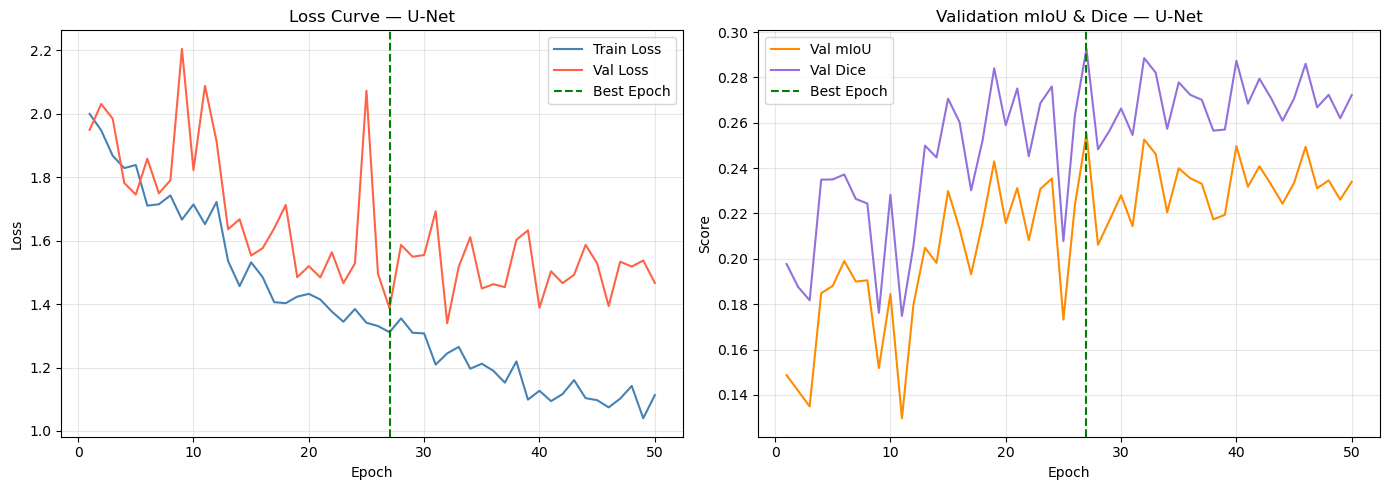

Training curves saved to: ../outputs/visual_results/unet_v2/training_curves.png


In [14]:
BEST_MODEL_PATH = SAVED_MODELS_DIR / f"best_{MODEL_NAME}.pth"

try:
    training_history = train_model(
        model        = model,
        train_loader = train_loader,
        val_loader   = val_loader,
        criterion    = criterion,
        num_epochs   = NUM_EPOCHS,
        learning_rate= LEARNING_RATE,
        device       = DEVICE,
        save_path    = BEST_MODEL_PATH
    )
    print(f"\nBest model saved to: {BEST_MODEL_PATH}")
    print(f"Best epoch          : {training_history['best_epoch']}")
    print(f"Best val mIoU       : {training_history['best_miou']:.4f}")

except Exception as exc:
    logger.error(f"Training failed: {exc}")
    raise

# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs, training_history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, training_history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best Epoch")
axes[0].set_title("Loss Curve — U-Net")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, training_history["val_miou"], label="Val mIoU", color="darkorange")
axes[1].plot(epochs, training_history["val_dice"], label="Val Dice", color="mediumpurple")
axes[1].axvline(training_history["best_epoch"], linestyle="--", color="green", label="Best Epoch")
axes[1].set_title("Validation mIoU & Dice — U-Net")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

curve_path = VISUAL_DIR / "training_curves.png"
plt.tight_layout()
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Training curves saved to: {curve_path}")

## Section 13 — Evaluate Task 1

Load the best saved model weights and run inference on all 15 test images.

In [15]:
# Load best weights
logger.info("Loading best model weights for Task 1 evaluation...")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

task1_results   = []   # list of dicts, one per test image
pred_masks_list = []   # predicted class masks
gt_masks_list   = []   # ground truth masks
image_names     = []   # image stem names

logger.info("Task 1 evaluation started...")

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        img_name = test_dataset.get_image_name(idx)
        image_names.append(img_name)

        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        # Measure inference time
        start_time = time.perf_counter()
        logits = model(images)
        if DEVICE.type == "mps":
            torch.mps.synchronize()
        elif DEVICE.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        inference_ms  = (end_time - start_time) * 1000.0
        fps           = 1000.0 / inference_ms if inference_ms > 0 else 0.0

        # Predicted mask via argmax
        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        gt_mask   = masks.squeeze(0).cpu().numpy().astype(np.uint8)

        pred_masks_list.append(pred_mask)
        gt_masks_list.append(gt_mask)

        # Compute Task 1 metrics
        metrics = compute_task1_metrics(pred_mask, gt_mask, NUM_CLASSES, IGNORE_INDEX)
        metrics["image_name"]     = img_name
        metrics["model_name"]     = MODEL_NAME
        metrics["inference_ms"]   = round(inference_ms, 2)
        metrics["fps"]            = round(fps, 2)
        task1_results.append(metrics)

        logger.info(
            f"[Task1] {img_name} | mIoU={metrics['mean_iou']:.4f} | "
            f"Dice={metrics['dice_score']:.4f} | {inference_ms:.1f}ms"
        )

logger.info(f"Task 1 evaluation completed for {len(task1_results)} images.")

# Summary
avg_miou   = np.mean([r["mean_iou"]       for r in task1_results])
avg_dice   = np.mean([r["dice_score"]     for r in task1_results])
avg_pacc   = np.mean([r["pixel_accuracy"] for r in task1_results])
avg_inf_ms = np.mean([r["inference_ms"]   for r in task1_results])

print(f"\nTask 1 Test Results — U-Net")
print(f"{'Avg Pixel Accuracy':<25}: {avg_pacc:.4f}")
print(f"{'Avg Mean IoU':<25}: {avg_miou:.4f}")
print(f"{'Avg Dice Score':<25}: {avg_dice:.4f}")
print(f"{'Avg Inference Time':<25}: {avg_inf_ms:.2f} ms")
print(f"{'Avg FPS':<25}: {1000/avg_inf_ms:.2f}")

2026-05-26 09:29:42 | INFO     | Loading best model weights for Task 1 evaluation...
2026-05-26 09:29:42 | INFO     | Task 1 evaluation started...
2026-05-26 09:29:42 | INFO     | [Task1] NLA_593684604EDR_F0722464NCAM00275M1 | mIoU=0.1300 | Dice=0.2152 | 50.8ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_398920191EDR_F0030078NCAM00304M1 | mIoU=0.2496 | Dice=0.2498 | 32.3ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_402463490EDR_F0043422NCAM00444M1 | mIoU=0.4317 | Dice=0.4629 | 33.0ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_412582904EDR_F0060000NCAM00366M1 | mIoU=0.1447 | Dice=0.1833 | 32.1ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_402380795EDR_F0043416NCAM00441M1 | mIoU=0.4420 | Dice=0.5519 | 32.4ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_408594626EDR_F0051398NCAM05134M1 | mIoU=0.2696 | Dice=0.2973 | 32.6ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_407536852EDR_F0050432NCAM07753M1 | mIoU=0.2173 | Dice=0.2325 | 32.2ms
2026-05-26 09:29:42 | INFO     | [Task1] NLA_408

## Section 14 — Generate Predicted Segmentation Masks

In [16]:
def mask_to_colour_image(
    mask: np.ndarray,
    colour_map: dict,
    ignore_index: int = 255
) -> np.ndarray:
    """
    Convert an integer class mask to an RGB colour image for visualisation.

    Args:
        mask        : (H, W) integer class array.
        colour_map  : {class_id: (R, G, B)} dict.
        ignore_index: NULL pixels rendered as black.

    Returns:
        (H, W, 3) uint8 RGB image.
    """
    h, w   = mask.shape
    colour = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, rgb in colour_map.items():
        colour[mask == cls_id] = rgb
    return colour


# Save predicted masks and compute paths for result table
pred_mask_paths = []

for idx, (pred_mask, img_name) in enumerate(zip(pred_masks_list, image_names)):
    pred_path = PRED_TASK1_DIR / f"{img_name}_pred_task1.png"

    # Save raw class mask (single-channel PNG for downstream use)
    Image.fromarray(pred_mask, mode="L").save(pred_path)
    pred_mask_paths.append(str(pred_path))

    # Update result record with path
    task1_results[idx]["pred_mask_path"] = str(pred_path)

logger.info(f"Task 1 predicted masks saved to: {PRED_TASK1_DIR}")
print(f"Predicted masks saved: {PRED_TASK1_DIR}")

2026-05-26 09:29:46 | INFO     | Task 1 predicted masks saved to: ../outputs/predictions_task1/unet_v2
Predicted masks saved: ../outputs/predictions_task1/unet_v2


## Section 15 — Evaluate Task 2

In [17]:
task2_results   = []
pred_trav_list  = []
gt_trav_list    = []

logger.info("Task 2 safe/unsafe conversion started...")

for idx, (pred_mask, gt_mask, img_name) in enumerate(
    zip(pred_masks_list, gt_masks_list, image_names)
):
    # Convert 4-class → binary traversability
    pred_trav = convert_to_traversability(pred_mask, TRAVERSABILITY_MAP, IGNORE_INDEX)
    gt_trav   = convert_to_traversability(gt_mask,   TRAVERSABILITY_MAP, IGNORE_INDEX)

    pred_trav_list.append(pred_trav)
    gt_trav_list.append(gt_trav)

    # Compute Task 2 metrics
    t2_m = compute_task2_metrics(pred_trav, gt_trav, IGNORE_INDEX)
    t2_m["image_name"] = img_name
    t2_m["model_name"] = MODEL_NAME
    task2_results.append(t2_m)

    logger.info(
        f"[Task2] {img_name} | Unsafe Recall={t2_m['unsafe_recall']:.4f} | "
        f"Hazard FNR={t2_m['hazard_fnr']:.4f}"
    )

logger.info(f"Task 2 metrics calculated for {len(task2_results)} images.")

avg_unsfR = np.mean([r["unsafe_recall"]        for r in task2_results])
avg_fnr   = np.mean([r["hazard_fnr"]           for r in task2_results])
avg_acc2  = np.mean([r["safe_unsafe_accuracy"]  for r in task2_results])
avg_f1_2  = np.mean([r["safe_unsafe_f1"]       for r in task2_results])

print(f"\nTask 2 Test Results — U-Net")
print(f"{'Safe/Unsafe Accuracy':<25}: {avg_acc2:.4f}")
print(f"{'Unsafe Recall':<25}: {avg_unsfR:.4f}")
print(f"{'Hazard FNR':<25}: {avg_fnr:.4f}")
print(f"{'Safe/Unsafe F1':<25}: {avg_f1_2:.4f}")

2026-05-26 09:29:48 | INFO     | Task 2 safe/unsafe conversion started...
2026-05-26 09:29:48 | INFO     | [Task2] NLA_593684604EDR_F0722464NCAM00275M1 | Unsafe Recall=0.0698 | Hazard FNR=0.9302
2026-05-26 09:29:48 | INFO     | [Task2] NLA_398920191EDR_F0030078NCAM00304M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-26 09:29:48 | INFO     | [Task2] NLA_402463490EDR_F0043422NCAM00444M1 | Unsafe Recall=0.8277 | Hazard FNR=0.1723
2026-05-26 09:29:48 | INFO     | [Task2] NLA_412582904EDR_F0060000NCAM00366M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-26 09:29:48 | INFO     | [Task2] NLA_402380795EDR_F0043416NCAM00441M1 | Unsafe Recall=0.7261 | Hazard FNR=0.2739
2026-05-26 09:29:48 | INFO     | [Task2] NLA_408594626EDR_F0051398NCAM05134M1 | Unsafe Recall=1.0000 | Hazard FNR=0.0000
2026-05-26 09:29:48 | INFO     | [Task2] NLA_407536852EDR_F0050432NCAM07753M1 | Unsafe Recall=0.0000 | Hazard FNR=0.0000
2026-05-26 09:29:48 | INFO     | [Task2] NLA_408331649EDR_F0050938NCAM00218M1 |

## Section 16 — Generate Safe/Unsafe Traversability Maps

In [18]:
trav_map_paths = []

for idx, (pred_trav, img_name) in enumerate(zip(pred_trav_list, image_names)):
    trav_path = TRAV_TASK2_DIR / f"{img_name}_trav_task2.png"

    # Save raw binary traversability mask
    Image.fromarray(pred_trav, mode="L").save(trav_path)
    trav_map_paths.append(str(trav_path))
    task2_results[idx]["trav_map_path"] = str(trav_path)

logger.info(f"Task 2 traversability maps saved to: {TRAV_TASK2_DIR}")
print(f"Traversability maps saved: {TRAV_TASK2_DIR}")

2026-05-26 09:29:49 | INFO     | Task 2 traversability maps saved to: ../outputs/traversability_task2/unet_v2
Traversability maps saved: ../outputs/traversability_task2/unet_v2


## Section 17 — Save Image-wise Results

In [19]:
# Merge Task 1 and Task 2 results into one record per image
combined_results = []

for t1, t2 in zip(task1_results, task2_results):
    row = {
        "image_name"           : t1["image_name"],
        "model_name"           : MODEL_NAME,
        # Task 1
        "pixel_accuracy"       : t1["pixel_accuracy"],
        "mean_iou"             : t1["mean_iou"],
        "dice_score"           : t1["dice_score"],
        "f1_score"             : t1["f1_score"],
        "soil_recall"          : t1["soil_recall"],
        "bedrock_recall"       : t1["bedrock_recall"],
        "sand_recall"          : t1["sand_recall"],
        "big_rock_recall"      : t1["big_rock_recall"],
        "inference_ms"         : t1["inference_ms"],
        "fps"                  : t1["fps"],
        "pred_mask_path"       : t1.get("pred_mask_path", ""),
        # Task 2
        "safe_unsafe_accuracy" : t2["safe_unsafe_accuracy"],
        "safe_precision"       : t2["safe_precision"],
        "unsafe_precision"     : t2["unsafe_precision"],
        "safe_recall"          : t2["safe_recall"],
        "unsafe_recall"        : t2["unsafe_recall"],
        "hazard_fnr"           : t2["hazard_fnr"],
        "safe_unsafe_f1"       : t2["safe_unsafe_f1"],
        "tp"                   : t2["tp"],
        "tn"                   : t2["tn"],
        "fp"                   : t2["fp"],
        "fn"                   : t2["fn"],
        "trav_map_path"        : t2.get("trav_map_path", ""),
    }
    combined_results.append(row)

print(f"Combined result records: {len(combined_results)}")
print("Image-wise results ready for Excel export.")

Combined result records: 75
Image-wise results ready for Excel export.


## Section 18 — Save Excel Result File

Creates `outputs/excel_results/unet_results.xlsx` with 6 sheets:  
Training_History · Task1_Image_Wise_Results · Task2_Image_Wise_Results · Task1_Overall_Summary · Task2_Overall_Summary · Final_Model_Conclusion

In [20]:
def style_header_row(ws, row_num: int, fill_colour: str = "4472C4"):
    """
    Apply bold font, white text, and coloured fill to a header row.

    Args:
        ws          : openpyxl worksheet.
        row_num     : 1-based row index.
        fill_colour : Hex colour string (no #).
    """
    fill  = PatternFill("solid", fgColor=fill_colour)
    font  = Font(bold=True, color="FFFFFF")
    for cell in ws[row_num]:
        if cell.value is not None:
            cell.font      = font
            cell.fill      = fill
            cell.alignment = Alignment(horizontal="center", wrap_text=True)


def apply_borders(ws, min_row: int, max_row: int, min_col: int, max_col: int):
    """Apply thin borders to all cells in a range."""
    thin = Side(style="thin")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    for row in ws.iter_rows(min_row=min_row, max_row=max_row,
                             min_col=min_col, max_col=max_col):
        for cell in row:
            cell.border = border


def auto_fit_columns(ws, padding: int = 4):
    """Adjust each column width to fit its longest value."""
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                max_len = max(max_len, len(str(cell.value or "")))
            except Exception:
                pass
        ws.column_dimensions[col_letter].width = min(max_len + padding, 50)


def build_excel_report(
    save_path: Path,
    training_history: dict,
    combined_results: list,
    model_name: str,
    num_params: int,
    model_size_mb: float
):
    """
    Build the full 6-sheet Excel result file for this model.

    Args:
        save_path        : Output .xlsx file path.
        training_history : Dict from train_model().
        combined_results : List of per-image result dicts.
        model_name       : String identifier.
        num_params       : Total trainable parameters.
        model_size_mb    : Model size in MB.
    """
    wb = openpyxl.Workbook()
    wb.remove(wb.active)   # remove default sheet

    # ─── Sheet 1: Training History ────────────────────────────────────────────
    ws1 = wb.create_sheet("Training_History")
    headers = ["Epoch", "Training Loss", "Validation Loss",
               "Validation Mean IoU", "Validation Dice Score"]
    ws1.append(headers)
    style_header_row(ws1, 1)

    for ep in range(len(training_history["train_loss"])):
        ws1.append([
            ep + 1,
            training_history["train_loss"][ep],
            training_history["val_loss"][ep],
            training_history["val_miou"][ep],
            training_history["val_dice"][ep],
        ])

    apply_borders(ws1, 1, ws1.max_row, 1, ws1.max_column)
    auto_fit_columns(ws1)
    ws1.freeze_panes = "A2"

    # ─── Sheet 2: Task1 Image-Wise ────────────────────────────────────────────
    ws2 = wb.create_sheet("Task1_Image_Wise_Results")
    t1_headers = [
        "Image Name", "Model Name", "Pixel Accuracy", "Mean IoU", "Dice Score",
        "F1-Score", "Soil Recall", "Bedrock Recall", "Sand Recall", "Big Rock Recall",
        "Inference Time ms", "FPS", "Prediction Mask Path"
    ]
    ws2.append(t1_headers)
    style_header_row(ws2, 1)

    for r in combined_results:
        ws2.append([
            r["image_name"], r["model_name"],
            r["pixel_accuracy"], r["mean_iou"], r["dice_score"], r["f1_score"],
            r["soil_recall"], r["bedrock_recall"], r["sand_recall"], r["big_rock_recall"],
            r["inference_ms"], r["fps"], r["pred_mask_path"]
        ])

    apply_borders(ws2, 1, ws2.max_row, 1, ws2.max_column)
    auto_fit_columns(ws2)
    ws2.freeze_panes = "A2"

    # ─── Sheet 3: Task2 Image-Wise ────────────────────────────────────────────
    ws3 = wb.create_sheet("Task2_Image_Wise_Results")
    t2_headers = [
        "Image Name", "Model Name", "Safe/Unsafe Accuracy", "Safe Precision",
        "Unsafe Precision", "Safe Recall", "Unsafe Recall", "Hazard FNR",
        "Safe/Unsafe F1-Score", "TP", "TN", "FP", "FN",
        "Safe/Unsafe Map Path", "Visual Output Path"
    ]
    ws3.append(t2_headers)
    style_header_row(ws3, 1)

    for r in combined_results:
        ws3.append([
            r["image_name"], r["model_name"],
            r["safe_unsafe_accuracy"], r["safe_precision"], r["unsafe_precision"],
            r["safe_recall"], r["unsafe_recall"], r["hazard_fnr"], r["safe_unsafe_f1"],
            r["tp"], r["tn"], r["fp"], r["fn"],
            r.get("trav_map_path", ""), r.get("visual_path", "")
        ])

    apply_borders(ws3, 1, ws3.max_row, 1, ws3.max_column)
    auto_fit_columns(ws3)
    ws3.freeze_panes = "A2"

    # ─── Sheet 4: Task1 Overall Summary ──────────────────────────────────────
    ws4 = wb.create_sheet("Task1_Overall_Summary")
    s1_headers = [
        "Model Name", "Average Pixel Accuracy", "Average Mean IoU",
        "Average Dice Score", "Average F1-Score",
        "Average Soil Recall", "Average Bedrock Recall",
        "Average Sand Recall", "Average Big Rock Recall",
        "Model Size MB", "Number of Parameters",
        "Average Inference Time ms", "Average FPS", "Remarks"
    ]
    ws4.append(s1_headers)
    style_header_row(ws4, 1)

    def _avg(key): return round(float(np.mean([r[key] for r in combined_results])), 4)

    avg_fps = round(1000 / _avg("inference_ms"), 2) if _avg("inference_ms") > 0 else 0
    ws4.append([
        model_name.upper(),
        _avg("pixel_accuracy"), _avg("mean_iou"), _avg("dice_score"), _avg("f1_score"),
        _avg("soil_recall"), _avg("bedrock_recall"), _avg("sand_recall"), _avg("big_rock_recall"),
        round(model_size_mb, 2), num_params, _avg("inference_ms"), avg_fps, "Baseline U-Net model"
    ])

    apply_borders(ws4, 1, ws4.max_row, 1, ws4.max_column)
    auto_fit_columns(ws4)

    # ─── Sheet 5: Task2 Overall Summary ──────────────────────────────────────
    ws5 = wb.create_sheet("Task2_Overall_Summary")
    s2_headers = [
        "Model Name", "Average Safe/Unsafe Accuracy", "Average Safe Precision",
        "Average Unsafe Precision", "Average Safe Recall", "Average Unsafe Recall",
        "Average Hazard FNR", "Average Safe/Unsafe F1-Score",
        "Total TP", "Total TN", "Total FP", "Total FN", "Remarks"
    ]
    ws5.append(s2_headers)
    style_header_row(ws5, 1)

    ws5.append([
        model_name.upper(),
        _avg("safe_unsafe_accuracy"), _avg("safe_precision"), _avg("unsafe_precision"),
        _avg("safe_recall"), _avg("unsafe_recall"), _avg("hazard_fnr"), _avg("safe_unsafe_f1"),
        sum(r["tp"] for r in combined_results), sum(r["tn"] for r in combined_results),
        sum(r["fp"] for r in combined_results), sum(r["fn"] for r in combined_results),
        "Baseline U-Net safety performance"
    ])

    apply_borders(ws5, 1, ws5.max_row, 1, ws5.max_column)
    auto_fit_columns(ws5)

    # ─── Sheet 6: Final Model Conclusion ─────────────────────────────────────
    ws6 = wb.create_sheet("Final_Model_Conclusion")
    c_headers = [
        "Model Name", "Best Strength", "Weakness",
        "Task 1 Summary", "Task 2 Summary", "Final Comment"
    ]
    ws6.append(c_headers)
    style_header_row(ws6, 1)
    ws6.append([
        "U-Net",
        "Stable encoder-decoder with skip connections",
        "Higher parameter count; no pretrained weights",
        f"Avg mIoU={_avg('mean_iou'):.4f}, Dice={_avg('dice_score'):.4f}",
        f"Unsafe Recall={_avg('unsafe_recall'):.4f}, Hazard FNR={_avg('hazard_fnr'):.4f}",
        "Solid baseline for Mars terrain segmentation"
    ])
    apply_borders(ws6, 1, ws6.max_row, 1, ws6.max_column)
    auto_fit_columns(ws6)

    wb.save(save_path)
    print(f"Excel report saved: {save_path}")


EXCEL_SAVE_PATH = EXCEL_DIR / f"{MODEL_NAME}_results.xlsx"

try:
    build_excel_report(
        save_path        = EXCEL_SAVE_PATH,
        training_history = training_history,
        combined_results = combined_results,
        model_name       = MODEL_NAME,
        num_params       = num_params,
        model_size_mb    = model_size_mb
    )
    logger.info(f"Excel file saved: {EXCEL_SAVE_PATH}")
except Exception as exc:
    logger.error(f"Excel save failed: {exc}")
    raise

Excel report saved: ../outputs/excel_results/unet_v2_results.xlsx
2026-05-26 09:29:52 | INFO     | Excel file saved: ../outputs/excel_results/unet_v2_results.xlsx


## Section 19 — Save Visual Outputs

For every test image, save a 5-panel comparison:  
Original · GT Class Mask · Predicted Class Mask · GT Traversability · Predicted Traversability

In [21]:
def save_visual_comparison(
    original_tensor: torch.Tensor,
    gt_mask: np.ndarray,
    pred_mask: np.ndarray,
    gt_trav: np.ndarray,
    pred_trav: np.ndarray,
    save_path: Path,
    image_name: str
):
    """
    Save a 5-panel side-by-side visual for one test image.

    Panels:
        1. Original Mars image
        2. Ground truth 4-class terrain mask
        3. Predicted 4-class terrain mask
        4. Ground truth safe/unsafe map
        5. Predicted safe/unsafe map
    """
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"U-Net | {image_name}", fontsize=11, fontweight="bold")

    # Panel 1: Original image
    img_np = original_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    axes[0].imshow(img_np, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Panels 2 & 3: Terrain masks
    gt_colour   = mask_to_colour_image(gt_mask,   CLASS_COLOURS, IGNORE_INDEX)
    pred_colour = mask_to_colour_image(pred_mask, CLASS_COLOURS, IGNORE_INDEX)

    axes[1].imshow(gt_colour)
    axes[1].set_title("GT Terrain Mask")
    axes[1].axis("off")

    axes[2].imshow(pred_colour)
    axes[2].set_title("Pred Terrain Mask")
    axes[2].axis("off")

    # Panels 4 & 5: Traversability maps
    gt_trav_colour   = mask_to_colour_image(gt_trav,   TRAV_COLOURS, IGNORE_INDEX)
    pred_trav_colour = mask_to_colour_image(pred_trav, TRAV_COLOURS, IGNORE_INDEX)

    axes[3].imshow(gt_trav_colour)
    axes[3].set_title("GT Safe/Unsafe")
    axes[3].axis("off")

    axes[4].imshow(pred_trav_colour)
    axes[4].set_title("Pred Safe/Unsafe")
    axes[4].axis("off")

    # Legends
    terrain_patches = [
        mpatches.Patch(color=np.array(c)/255, label=n)
        for n, c in zip(CLASS_NAMES, CLASS_COLOURS.values())
    ]
    fig.legend(handles=terrain_patches, loc="lower center",
               ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# Save visuals for ALL test images
logger.info("Saving visual comparison images...")

for idx in range(len(test_dataset)):
    img_name  = image_names[idx]
    vis_path  = VISUAL_DIR / f"{img_name}_visual.png"

    orig_tensor, _ = test_dataset[idx]

    save_visual_comparison(
        original_tensor = orig_tensor,
        gt_mask         = gt_masks_list[idx],
        pred_mask       = pred_masks_list[idx],
        gt_trav         = gt_trav_list[idx],
        pred_trav       = pred_trav_list[idx],
        save_path       = vis_path,
        image_name      = img_name
    )

    combined_results[idx]["visual_path"] = str(vis_path)

logger.info(f"Visual results saved to: {VISUAL_DIR}")
print(f"Visual outputs saved: {VISUAL_DIR}")
print(f"Total visuals saved : {len(test_dataset)}")

2026-05-26 09:29:54 | INFO     | Saving visual comparison images...
2026-05-26 09:30:16 | INFO     | Visual results saved to: ../outputs/visual_results/unet_v2
Visual outputs saved: ../outputs/visual_results/unet_v2
Total visuals saved : 75


## Section 20 — Final Summary

In [22]:
def _avg(key): return round(float(np.mean([r[key] for r in combined_results])), 4)

print("\n" + "="*65)
print(f"  FINAL SUMMARY — U-Net (EXP-01)")
print("="*65)

print(f"\n  MODEL INFO")
print(f"    Model Name        : U-Net (Baseline)")
print(f"    Parameters        : {num_params:,}")
print(f"    Model Size        : {model_size_mb:.2f} MB")
print(f"    Best Epoch        : {training_history['best_epoch']}")
print(f"    Best Val mIoU     : {training_history['best_miou']:.4f}")

print(f"\n  TASK 1 — TERRAIN SEGMENTATION (Test Set, 15 images)")
print(f"    Pixel Accuracy    : {_avg('pixel_accuracy'):.4f}")
print(f"    Mean IoU          : {_avg('mean_iou'):.4f}")
print(f"    Dice Score        : {_avg('dice_score'):.4f}")
print(f"    F1-Score          : {_avg('f1_score'):.4f}")
print(f"    Soil Recall       : {_avg('soil_recall'):.4f}")
print(f"    Bedrock Recall    : {_avg('bedrock_recall'):.4f}")
print(f"    Sand Recall       : {_avg('sand_recall'):.4f}")
print(f"    Big Rock Recall   : {_avg('big_rock_recall'):.4f}")
print(f"    Avg Inference     : {_avg('inference_ms'):.2f} ms")
print(f"    Avg FPS           : {_avg('fps'):.2f}")

print(f"\n  TASK 2 — SAFE/UNSAFE TRAVERSABILITY")
print(f"    Accuracy          : {_avg('safe_unsafe_accuracy'):.4f}")
print(f"    Unsafe Recall ★   : {_avg('unsafe_recall'):.4f}")
print(f"    Hazard FNR ★      : {_avg('hazard_fnr'):.4f}")
print(f"    Safe/Unsafe F1    : {_avg('safe_unsafe_f1'):.4f}")
print(f"    Safe Precision    : {_avg('safe_precision'):.4f}")
print(f"    Unsafe Precision  : {_avg('unsafe_precision'):.4f}")
total_tp = sum(r['tp'] for r in combined_results)
total_tn = sum(r['tn'] for r in combined_results)
total_fp = sum(r['fp'] for r in combined_results)
total_fn = sum(r['fn'] for r in combined_results)
print(f"    Confusion Matrix  : TP={total_tp}, TN={total_tn}, FP={total_fp}, FN={total_fn}")

print(f"\n  OUTPUTS SAVED")
print(f"    Model weights     : {BEST_MODEL_PATH}")
print(f"    Pred masks        : {PRED_TASK1_DIR}")
print(f"    Trav maps         : {TRAV_TASK2_DIR}")
print(f"    Visuals           : {VISUAL_DIR}")
print(f"    Excel report      : {EXCEL_SAVE_PATH}")
print(f"    Log file          : {LOG_PATH}")
print("="*65)

logger.info("========== U-NET NOTEBOOK COMPLETED SUCCESSFULLY ==========")


  FINAL SUMMARY — U-Net (EXP-01)

  MODEL INFO
    Model Name        : U-Net (Baseline)
    Parameters        : 31,385,028
    Model Size        : 119.72 MB
    Best Epoch        : 27
    Best Val mIoU     : 0.2552

  TASK 1 — TERRAIN SEGMENTATION (Test Set, 15 images)
    Pixel Accuracy    : 0.7595
    Mean IoU          : 0.2402
    Dice Score        : 0.2751
    F1-Score          : 0.2751
    Soil Recall       : 0.5549
    Bedrock Recall    : 0.3009
    Sand Recall       : 0.1820
    Big Rock Recall   : 0.1282
    Avg Inference     : 32.64 ms
    Avg FPS           : 30.73

  TASK 2 — SAFE/UNSAFE TRAVERSABILITY
    Accuracy          : 0.8675
    Unsafe Recall ★   : 0.2913
    Hazard FNR ★      : 0.1887
    Safe/Unsafe F1    : 0.5226
    Safe Precision    : 0.9148
    Unsafe Precision  : 0.2090
    Confusion Matrix  : TP=200104, TN=2416461, FP=196746, FN=120023

  OUTPUTS SAVED
    Model weights     : ../outputs/saved_models/unet_v2/best_unet_v2.pth
    Pred masks        : ../outputs/